Accuracy : 0.9210526315789473
Precision: 1.0
Recall   : 0.4
F1-score : 0.5714285714285714

Classification Report:

              precision    recall  f1-score   support

    IO-bound       0.92      1.00      0.96        33
   CPU-bound       1.00      0.40      0.57         5

    accuracy                           0.92        38
   macro avg       0.96      0.70      0.76        38
weighted avg       0.93      0.92      0.91        38



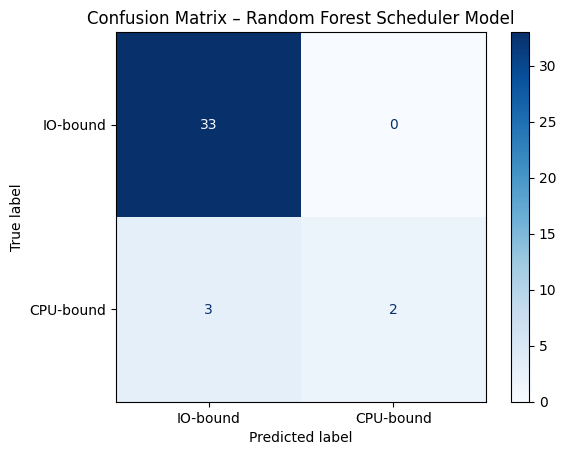

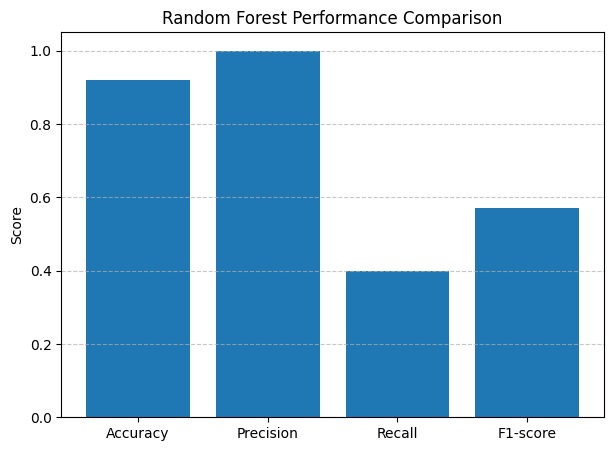

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# -------------------------------------------------
# Load eBPF scheduler dataset
# -------------------------------------------------
df = pd.read_csv("/content/sched_4F_05seconds.csv")

# -------------------------------------------------
# Aggregate scheduler events per PID
# -------------------------------------------------
runtime = df[df.event == "sched_runtime"].groupby("pid")["value"].agg(
    total_runtime_ns="sum",
    avg_runtime_ns="mean"
)

wait = df[df.event == "sched_wait"].groupby("pid")["value"].agg(
    total_wait_ns="sum",
    avg_wait_ns="mean"
)

wakeup = df[df.event == "sched_wakeup"].groupby("pid").size().rename("wakeup_count")
switch = df[df.event == "sched_switch"].groupby("pid").size().rename("switch_count")

features = (
    runtime.join(wait, how="outer")
           .join(wakeup, how="outer")
           .join(switch, how="outer")
           .fillna(0)
)

# -------------------------------------------------
# Derived scheduler features (NO LEAKAGE)
# -------------------------------------------------
features["runtime_per_switch"] = features["total_runtime_ns"] / (features["switch_count"] + 1)
features["wakeup_ratio"] = features["wakeup_count"] / (features["switch_count"] + 1)

# -------------------------------------------------
# Real scheduler-based label
# CPU-bound = high runtime + low wakeups
# IO-bound  = low runtime + high wakeups
# -------------------------------------------------
runtime_thr = features["total_runtime_ns"].median()
wakeup_thr = features["wakeup_count"].median()

features["label"] = (
    (features["total_runtime_ns"] > runtime_thr) &
    (features["wakeup_count"] < wakeup_thr)
).astype(int)

# -------------------------------------------------
# Train / Test split (NO PID LEAKAGE)
# -------------------------------------------------
X = features.drop(columns="label")
y = features["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# Random Forest model
# -------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# -------------------------------------------------
# Evaluation metrics
# -------------------------------------------------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["IO-bound", "CPU-bound"]))

# -------------------------------------------------
# Confusion Matrix
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["IO-bound", "CPU-bound"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Random Forest Scheduler Model")
plt.show()

# -------------------------------------------------
# Metric Comparison Graph
# -------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Random Forest Performance Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



===== kNN RESULTS =====
Accuracy : 0.8421052631578947
Precision: 0.3333333333333333
Recall   : 0.2
F1-score : 0.25

Classification Report:

              precision    recall  f1-score   support

    IO-bound       0.89      0.94      0.91        33
   CPU-bound       0.33      0.20      0.25         5

    accuracy                           0.84        38
   macro avg       0.61      0.57      0.58        38
weighted avg       0.81      0.84      0.82        38



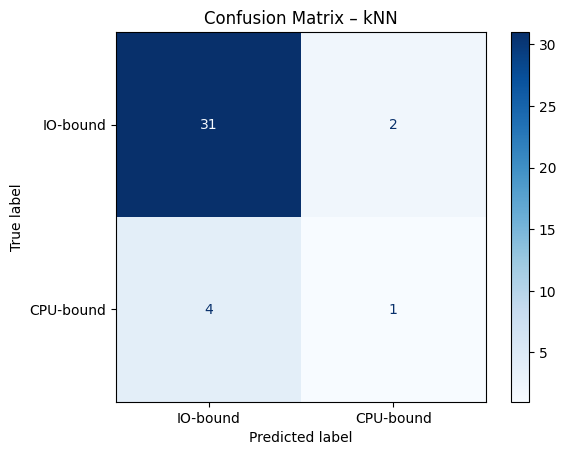

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Load dataset
df = pd.read_csv("/content/sched_4F_05sec.csv")

# Aggregate features
runtime = df[df.event == "sched_runtime"].groupby("pid")["value"].agg(
    total_runtime_ns="sum",
    avg_runtime_ns="mean"
)

wait = df[df.event == "sched_wait"].groupby("pid")["value"].agg(
    total_wait_ns="sum",
    avg_wait_ns="mean"
)

wakeup = df[df.event == "sched_wakeup"].groupby("pid").size().rename("wakeup_count")
switch = df[df.event == "sched_switch"].groupby("pid").size().rename("switch_count")

features = runtime.join(wait, how="outer") \
                  .join(wakeup, how="outer") \
                  .join(switch, how="outer") \
                  .fillna(0)

# Derived features
features["runtime_per_switch"] = features["total_runtime_ns"] / (features["switch_count"] + 1)
features["wakeup_ratio"] = features["wakeup_count"] / (features["switch_count"] + 1)

# Labels
runtime_thr = features["total_runtime_ns"].median()
wakeup_thr = features["wakeup_count"].median()

features["label"] = (
    (features["total_runtime_ns"] > runtime_thr) &
    (features["wakeup_count"] < wakeup_thr)
).astype(int)

X = features.drop(columns="label")
y = features["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scaling (MANDATORY for kNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# kNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Metrics
print("\n===== kNN RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["IO-bound", "CPU-bound"]))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["IO-bound", "CPU-bound"]
).plot(cmap="Blues")
plt.title("Confusion Matrix – kNN")
plt.show()



===== GRADIENT BOOSTING RESULTS =====
Accuracy : 0.9473684210526315
Precision: 1.0
Recall   : 0.6
F1-score : 0.75

Classification Report:

              precision    recall  f1-score   support

    IO-bound       0.94      1.00      0.97        33
   CPU-bound       1.00      0.60      0.75         5

    accuracy                           0.95        38
   macro avg       0.97      0.80      0.86        38
weighted avg       0.95      0.95      0.94        38



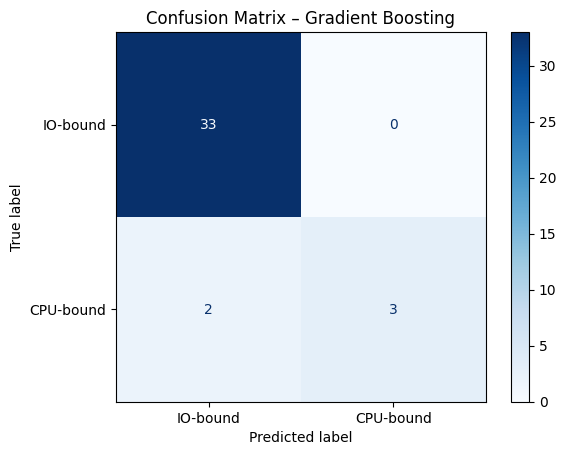

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

df = pd.read_csv("/content/sched_4F_05sec.csv")

runtime = df[df.event == "sched_runtime"].groupby("pid")["value"].agg(
    total_runtime_ns="sum",
    avg_runtime_ns="mean"
)

wait = df[df.event == "sched_wait"].groupby("pid")["value"].agg(
    total_wait_ns="sum",
    avg_wait_ns="mean"
)

wakeup = df[df.event == "sched_wakeup"].groupby("pid").size().rename("wakeup_count")
switch = df[df.event == "sched_switch"].groupby("pid").size().rename("switch_count")

features = runtime.join(wait, how="outer") \
                  .join(wakeup, how="outer") \
                  .join(switch, how="outer") \
                  .fillna(0)

features["runtime_per_switch"] = features["total_runtime_ns"] / (features["switch_count"] + 1)
features["wakeup_ratio"] = features["wakeup_count"] / (features["switch_count"] + 1)

runtime_thr = features["total_runtime_ns"].median()
wakeup_thr = features["wakeup_count"].median()

features["label"] = (
    (features["total_runtime_ns"] > runtime_thr) &
    (features["wakeup_count"] < wakeup_thr)
).astype(int)

X = features.drop(columns="label")
y = features["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

print("\n===== GRADIENT BOOSTING RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["IO-bound", "CPU-bound"]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["IO-bound", "CPU-bound"]
).plot(cmap="Blues")
plt.title("Confusion Matrix – Gradient Boosting")
plt.show()



===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 0.868421052631579
Precision: 0.5
Recall   : 0.2
F1-score : 0.2857142857142857

Classification Report:

              precision    recall  f1-score   support

    IO-bound       0.89      0.97      0.93        33
   CPU-bound       0.50      0.20      0.29         5

    accuracy                           0.87        38
   macro avg       0.69      0.58      0.61        38
weighted avg       0.84      0.87      0.84        38



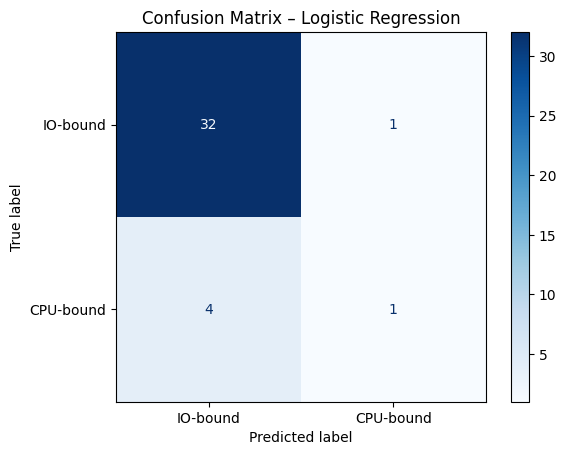

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

df = pd.read_csv("/content/sched_4F_05sec.csv")

runtime = df[df.event == "sched_runtime"].groupby("pid")["value"].agg(
    total_runtime_ns="sum",
    avg_runtime_ns="mean"
)

wait = df[df.event == "sched_wait"].groupby("pid")["value"].agg(
    total_wait_ns="sum",
    avg_wait_ns="mean"
)

wakeup = df[df.event == "sched_wakeup"].groupby("pid").size().rename("wakeup_count")
switch = df[df.event == "sched_switch"].groupby("pid").size().rename("switch_count")

features = runtime.join(wait, how="outer") \
                  .join(wakeup, how="outer") \
                  .join(switch, how="outer") \
                  .fillna(0)

features["runtime_per_switch"] = features["total_runtime_ns"] / (features["switch_count"] + 1)
features["wakeup_ratio"] = features["wakeup_count"] / (features["switch_count"] + 1)

runtime_thr = features["total_runtime_ns"].median()
wakeup_thr = features["wakeup_count"].median()

features["label"] = (
    (features["total_runtime_ns"] > runtime_thr) &
    (features["wakeup_count"] < wakeup_thr)
).astype(int)

X = features.drop(columns="label")
y = features["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scaling (MANDATORY for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["IO-bound", "CPU-bound"]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["IO-bound", "CPU-bound"]
).plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()
